### TeleCo Customer Churn Prediction & AI Retention

Develop an end-to-end AI solution that:

Predicts which customers are likely to churn.
Assists customer retention representatives with personalized recommendations during customer interactions.

### Predictive Churn Model
Problem Statement

Predict whether a customer will churn (Yes/No) using historical customer data.

### Essential libraries

In [81]:
# Import essential libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import math
from scipy import stats

from pathlib import Path

import seaborn as sns
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")


In [3]:
print("Data Preprocessing & Feature Engineering")
print("="*60)
print("Dataset: Customers Churn data (17 features)")
print("Goal: Transform raw data into ML-ready features")

Data Preprocessing & Feature Engineering
Dataset: Customers Churn data (17 features)
Goal: Transform raw data into ML-ready features


### Load  Dataset
Loading the TeleCo Customer Churn dataset with Cutomers Id's, Tenure, Contract Type, Avg Monthly GB usage and churned data.

In [ ]:
# Folder containing CSV files
folder_path = Path(r"D:\Churn_Prediction\data\raw_data")

# Get all CSV files
csv_files = list(folder_path.glob("*.csv"))

if not csv_files:
    print("No CSV files found in the folder.")
else:
    # Load the first CSV file
    data_path = csv_files[0]

    try:
        df = pd.read_csv(data_path)
        print(f"Successfully loaded: {data_path.name}")
        print(f"\nDataset shape: {df.shape}")
        print(f"\nColumns: {df.columns}")
    except Exception as e:
        print(f"Error: {e}")

Successfully loaded: test_datafile.csv

Dataset shape: (5050, 17)

Columns: Index(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'monthly_charges', 'total_charges', 'internet_service', 'phone_service',
       'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes',
       'satisfaction_score', 'payment_method', 'num_additional_services',
       'last_interaction_date', 'churned'],
      dtype='object')


##  Part 1: Initial Data Exploration

In [5]:
# Quick data overview
print(f"Total students: {len(df)}")
print(f"Features: {df.shape[1]}")
print("\nFirst 3 records:")
df.head(3)

Total students: 5050
Features: 17

First 3 records:


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,7.8,bank transfer,2,2024-06-14,1
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,no,9.46,1.0,306.8,6.0,Electronic check,5,2024-06-23,1
2,TC-000066,62.343600,male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,5.5,Bank transfer,0,2024-06-21,0


#### Comprehensive Dataset Overview

Our customer churn dataset contains multiple categories of features that provide a comprehensive view of each customer's profile, service usage, billing behavior, and overall satisfaction.

**Column Categories:**

- **Customer Identity:** customer_id
- **Demographics:** age, gender
- **Account Information:** tenure_months, contract_type
- **Billing & Payments:** monthly_charges, total_charges, payment_method
- **Services Subscribed:** internet_service, phone_service, num_additional_services
- **Usage Metrics:** avg_monthly_gb_used, avg_monthly_minutes
- **Customer Support & Engagement:** num_support_tickets, last_interaction_date
- **Customer Satisfaction:** satisfaction_score
- **Target Variable:** churned

#### Data Quality Assessment

In [6]:
# Check data types and missing values
print("\nDATA QUALITY CHECK")
print("="*30)
print("\nData Types:")
print(df.dtypes)
# print(f"\nMissing Values:")
# missing_summary = df.isnull().sum()
# print(missing_summary[missing_summary > 0])
# print(f"\nDuplicate Records: {df.duplicated().sum()}")


DATA QUALITY CHECK

Data Types:
customer_id                 object
age                        float64
gender                      object
tenure_months              float64
contract_type               object
monthly_charges            float64
total_charges              float64
internet_service            object
phone_service               object
avg_monthly_gb_used        float64
num_support_tickets        float64
avg_monthly_minutes        float64
satisfaction_score         float64
payment_method              object
num_additional_services      int64
last_interaction_date       object
churned                      int64
dtype: object


In [7]:
print(f"\nMissing Values:")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])
print(f"\nDuplicate Records: {df.duplicated().sum()}")


Missing Values:
age                     10
gender                  50
tenure_months           11
monthly_charges         12
total_charges           23
internet_service       505
avg_monthly_gb_used     15
avg_monthly_minutes     82
satisfaction_score      20
payment_method          30
dtype: int64

Duplicate Records: 50


In [8]:
print("\nDataFrame Info:")
df.info(verbose = True) 


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5050 non-null   object 
 1   age                      5040 non-null   float64
 2   gender                   5000 non-null   object 
 3   tenure_months            5039 non-null   float64
 4   contract_type            5050 non-null   object 
 5   monthly_charges          5038 non-null   float64
 6   total_charges            5027 non-null   float64
 7   internet_service         4545 non-null   object 
 8   phone_service            5050 non-null   object 
 9   avg_monthly_gb_used      5035 non-null   float64
 10  num_support_tickets      5050 non-null   float64
 11  avg_monthly_minutes      4968 non-null   float64
 12  satisfaction_score       5030 non-null   float64
 13  payment_method           5020 non-null   object 
 14  num_add

In [9]:
# Statistical summary for numerical columns
print("NUMERICAL FEATURES SUMMARY")
print("="*26)
df.describe().T

NUMERICAL FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,5040.0,42.752631,24.003502,-1.00000,31.978442,42.193729,52.026286,999.00
tenure_months,5039.0,24.092848,24.343918,-12.00000,6.837390,16.483189,33.823095,500.00
monthly_charges,5038.0,69.921683,211.202935,-50.00000,47.532500,65.050000,82.250000,9999.00
total_charges,5027.0,1642.319540,4183.374844,0.66000,372.280000,953.640000,2122.525000,218681.58
avg_monthly_gb_used,5035.0,15.153484,15.601767,-86.55345,4.425000,10.360000,21.625000,119.67
num_support_tickets,5050.0,2.270099,12.218691,-5.00000,1.000000,2.000000,3.000000,500.00
avg_monthly_minutes,4968.0,299.333394,117.937511,0.00000,215.400000,299.250000,378.225000,747.50
satisfaction_score,5030.0,6.098708,3.333432,-1.40000,4.600000,6.000000,7.400000,99.00
num_additional_services,5050.0,2.483366,1.711466,0.00000,1.000000,2.000000,4.000000,5.00
churned,5050.0,0.363762,0.481129,0.00000,0.000000,0.000000,1.000000,1.00


## Part 2: Problem Definition & Target Variables

### Analyze Variables
#### Target Analysis


Text(0.5, 1.02, 'Count of TARGET Variable per category')

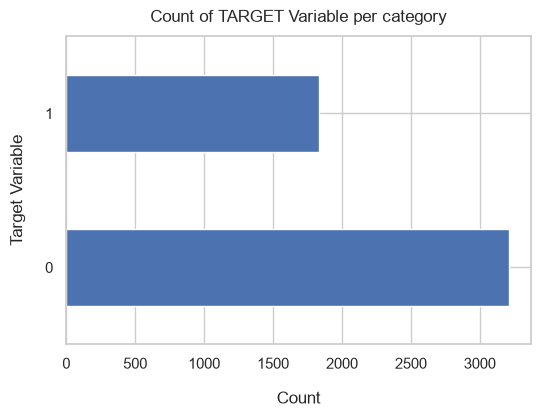

In [10]:
df['churned'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02)

In [11]:
# Classification target analysis
churn_counts = df['churned'].value_counts()
churn_rate = df['churned'].mean()

print("Churn Distribution:")
print(f"  Not Churned (0): {churn_counts[0]} customers ({(1-churn_rate):.1%})")
print(f"  Churned (1):     {churn_counts[1]} customers ({churn_rate:.1%})")
print(f"\nOverall Churn Rate: {churn_rate:.1%}")

# Check for class imbalance
if churn_rate < 0.3 or churn_rate > 0.7:
    print("Class imbalance detected - will need stratified sampling")
else:
    print("Balanced classes - good for training")

Churn Distribution:
  Not Churned (0): 3213 customers (63.6%)
  Churned (1):     1837 customers (36.4%)

Overall Churn Rate: 36.4%
Balanced classes - good for training


However, the statement:

~ `Balanced classes - good for training`

is **`not entirely accurate`**.

A dataset with `63.6% vs. 36.4%` is moderately imbalanced, not perfectly balanced. It is generally `acceptable` for training many machine learning models, but it is not considered a balanced dataset.

#### Understanding Class Imbalance Thresholds

**Why 0.3 to 0.7 range for balanced classes?**

This range represents the "reasonably balanced" zone where:
- **Below 30%**: Severe minority class - most algorithms will struggle
- **30-70%**: Manageable imbalance - algorithms can learn both classes effectively
- **Above 70%**: Severe majority class - model might ignore minority class

In our case, if `churn rate` is outside `30-70%`, we need stratified sampling to ensure both training and test sets have similar class distributions.

## Part 3: Data Cleaning & Quality Issues

#### Data Standardization
 ~ `Normalize text` case to avoid `duplicate categories` caused by variations in capitalization.

 ~ Mapped abbreviations and alternative representations (e.g., M → Male, CC → Credit Card, Y → Yes) to standardized values.

In [12]:
# print("\nGender:")
# print(df['gender'].value_counts())

print("\nInternet Service:")
print(df['internet_service'].value_counts())

# print("\nPhone Service:")
# print(df['phone_service'].value_counts())

# print("\nPayment Method:")
# print(df['payment_method'].value_counts())

# print("\nContract Type:")
# print(df['contract_type'].value_counts())


Internet Service:
internet_service
Fiber optic    1721
DSL            1278
No              736
fiber           440
dsl             370
Name: count, dtype: int64


In [13]:
# ==============================
# Data Standardization
# ==============================

# Gender standardization
df['gender'] = (
    df['gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'male': 'Male',
        'm': 'Male',
        'female': 'Female',
        'f': 'Female',
        'other': 'Other'
    })
)

# Internet service standardization
df['internet_service'] = (
    df['internet_service']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'fiber optic': 'Fiber optic',
        'fiber': 'Fiber',
        'dsl': 'DSL',
        'no': 'No'
    })
)

# Phone service standardization
df['phone_service'] = (
    df['phone_service']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 'Yes',
        'y': 'Yes',
        'no': 'No',
        'n': 'No'
    })
)

# Payment method standardization
df['payment_method'] = (
    df['payment_method']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'credit card': 'Credit card',
        'cc': 'Credit card',
        'bank transfer': 'Bank transfer',
        'bt': 'Bank transfer',
        'electronic check': 'Electronic check',
        'mailed check': 'Mailed check'
    })
)

# Contract type standardization
df['contract_type'] = ( 
    df['contract_type']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'month-to-month': 'Month-to-month',
        'one year': 'One year',
        'two year': 'Two year'
    })
)

In [14]:
print("\nInternet Service:")
print(df['internet_service'].value_counts())



Internet Service:
internet_service
Fiber optic    1721
DSL            1648
No              736
nan             505
Fiber           440
Name: count, dtype: int64


In [15]:
df = df.replace('nan', np.nan)

#### Duplicate customer IDs

In [16]:
# Display duplicate rows based on customer_id
duplicate_rows = df[df.duplicated(subset=["customer_id"], keep=False)]

print("\nDuplicate customer IDs:")
duplicate_rows


Duplicate customer IDs:


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.700000,4.0,324.0,7.8,Bank transfer,2,2024-06-14,1
34,TC-001145,39.403923,Male,4.400608,Two year,74.25,320.27,No,Yes,3.350000,4.0,355.4,2.2,Electronic check,5,2024-06-06,0
76,TC-002787,30.450059,Male,48.480751,One year,57.37,2784.99,Fiber optic,Yes,44.940000,2.0,118.9,6.8,Credit card,2,2024-02-26,0
204,TC-004940,20.998939,Male,20.145723,Month-to-month,65.60,1447.34,No,Yes,7.100000,2.0,271.1,2.6,Credit card,3,2024-05-26,0
301,TC-000385,30.613010,Female,69.584358,Month-to-month,69.10,4757.33,Fiber optic,Yes,13.510000,3.0,52.3,5.5,Mailed check,0,2024-05-30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4792,TC-003068,42.276024,Male,15.065428,Month-to-month,59.76,946.07,Fiber optic,Yes,31.550000,1.0,408.1,4.9,Electronic check,4,2024-04-07,0
4844,TC-002763,55.430331,Female,3.303473,One year,120.29,404.02,Fiber optic,Yes,0.240000,0.0,424.1,3.1,Credit card,0,2024-06-03,0
4905,TC-004745,66.065087,Female,83.041357,One year,15.00,1193.04,DSL,No,9.760000,2.0,279.1,6.8,Bank transfer,3,2024-06-14,0
4917,TC-002054,37.444110,Female,4.038543,Month-to-month,29.80,119.12,Fiber,Yes,-45.861245,1.0,455.7,7.8,Electronic check,0,2024-05-10,1


In [17]:
# Count duplicate customer IDs 
duplicates = df.duplicated(subset=["customer_id"]).sum()
print(f"Number of duplicate customer IDs: {duplicates}")

Number of duplicate customer IDs: 50


*Observation:*

The dataset contained **50** duplicate Customer IDs, indicating that some customers had more than one record in the dataset.

In [18]:
## display duplicate customer IDs 

# duplicate_rows[duplicate_rows["customer_id"] == "TC-001145"]

# df[df["customer_id"] == "TC-004711"]

duplicate_rows[duplicate_rows["customer_id"] == "TC-004711"]

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.7,4.0,324.0,7.8,Bank transfer,2,2024-06-14,1
2087,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.7,4.0,324.0,7.8,Bank transfer,2,2024-06-14,1


In [19]:
# Find duplicate records based on customer_id + contract_type + monthly_charges
duplicate_rows = df[
    df.duplicated(
        subset=["customer_id", "contract_type", "monthly_charges"],
        keep=False
    )
]

print(f"Number of duplicate rows: {len(duplicate_rows)}")

duplicate_rows

Number of duplicate rows: 100


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.700000,4.0,324.0,7.8,Bank transfer,2,2024-06-14,1
34,TC-001145,39.403923,Male,4.400608,Two year,74.25,320.27,No,Yes,3.350000,4.0,355.4,2.2,Electronic check,5,2024-06-06,0
76,TC-002787,30.450059,Male,48.480751,One year,57.37,2784.99,Fiber optic,Yes,44.940000,2.0,118.9,6.8,Credit card,2,2024-02-26,0
204,TC-004940,20.998939,Male,20.145723,Month-to-month,65.60,1447.34,No,Yes,7.100000,2.0,271.1,2.6,Credit card,3,2024-05-26,0
301,TC-000385,30.613010,Female,69.584358,Month-to-month,69.10,4757.33,Fiber optic,Yes,13.510000,3.0,52.3,5.5,Mailed check,0,2024-05-30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4792,TC-003068,42.276024,Male,15.065428,Month-to-month,59.76,946.07,Fiber optic,Yes,31.550000,1.0,408.1,4.9,Electronic check,4,2024-04-07,0
4844,TC-002763,55.430331,Female,3.303473,One year,120.29,404.02,Fiber optic,Yes,0.240000,0.0,424.1,3.1,Credit card,0,2024-06-03,0
4905,TC-004745,66.065087,Female,83.041357,One year,15.00,1193.04,DSL,No,9.760000,2.0,279.1,6.8,Bank transfer,3,2024-06-14,0
4917,TC-002054,37.444110,Female,4.038543,Month-to-month,29.80,119.12,Fiber,Yes,-45.861245,1.0,455.7,7.8,Electronic check,0,2024-05-10,1


In [20]:
customer_connections = (
    df.groupby("customer_id")
      .agg(
          total_connections=("customer_id", "count"),
          unique_contracts=("contract_type", "nunique"),
          unique_monthly_charges=("monthly_charges", "nunique"),
          unique_internet_services=("internet_service", "nunique"),
          unique_phone_services=("phone_service", "nunique"),
          unique_total_charges=("total_charges", "nunique")
      )
      .reset_index()
)

# Customers with multiple connections (different service/contract details)
real_multiple_connections = customer_connections.query(
    "total_connections > 1 and "
    "(unique_contracts > 1 or "
    "unique_monthly_charges > 1 or "
    "unique_internet_services > 1 or "
    "unique_phone_services > 1 or "
    "unique_total_charges > 1)"
)

real_multiple_connections

count = len(real_multiple_connections)

print(f"Number of customers with multiple connections: {count}")

Number of customers with multiple connections: 0


Customers with Multiple connections: 0

`Multiple records` - `True duplicate` records caused by repeated data entry,

the `Last Interaction Date` was used to identify the most recent customer information.

In [21]:
## Converted to datetime format for accurate date comparison, Sorted by Customer ID and Last Interaction Date (latest first)

# Convert last_interaction_date to datetime
df["last_interaction_date"] = pd.to_datetime(df["last_interaction_date"])

# Sort by customer and keep the latest interaction record
df = df.sort_values(
    by=["customer_id", "last_interaction_date"],
    ascending=[True, False]
)

# Remove duplicate customers, keeping the most recent record
df = df.drop_duplicates(
    subset=["customer_id"],
    keep="first"
)

print("Dataset shape after removing duplicates:", df.shape)

print(
    "Remaining duplicate customer IDs:",
    df.duplicated(subset=["customer_id"]).sum()
)

Dataset shape after removing duplicates: (5000, 17)
Remaining duplicate customer IDs: 0


#### Missing Values

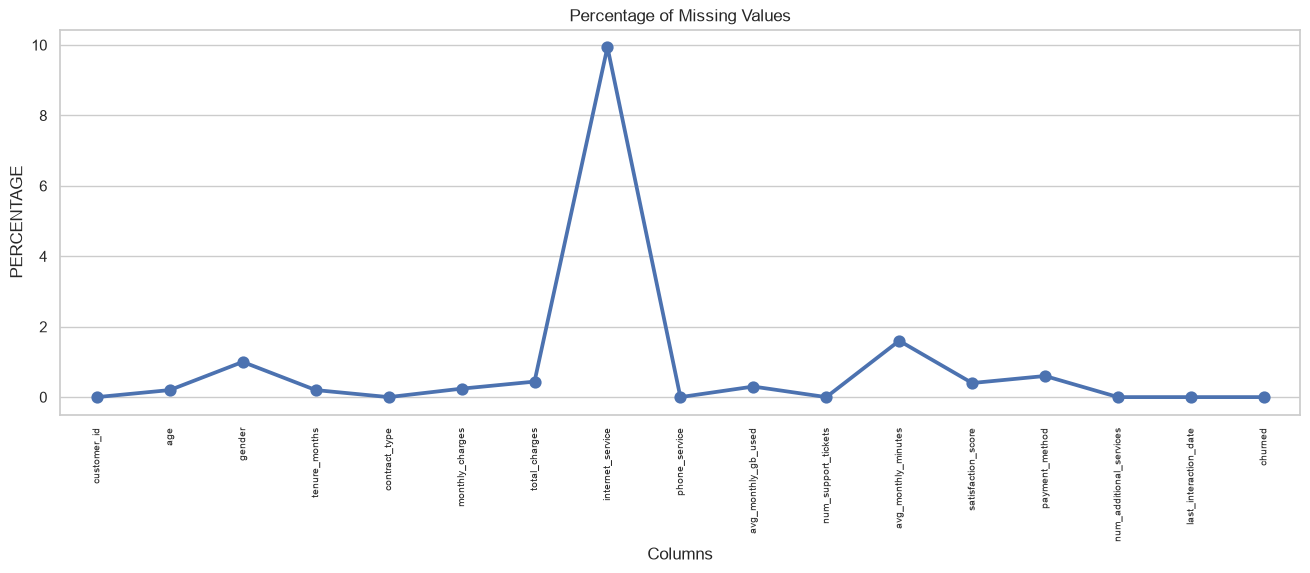

In [22]:
missing = pd.DataFrame((df.isnull().sum()) * 100 / df.shape[0]).reset_index()

plt.figure(figsize=(16,5))

ax = sns.pointplot(x='index', y=0, data=missing)

plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing Values")
plt.ylabel("PERCENTAGE")
plt.xlabel("Columns")
plt.show()

In [23]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column", "Missing Count"]

missing["Percentage"] = (
    missing["Missing Count"] / len(df)
) * 100

# # Show only columns with missing values
missing = missing[missing["Missing Count"] > 0]

missing

,Column,Missing Count,Percentage
0,internet_service,497,9.94
1,avg_monthly_minutes,80,1.60
2,gender,50,1.00
3,payment_method,30,0.60
4,total_charges,22,0.44
5,satisfaction_score,20,0.40
6,avg_monthly_gb_used,15,0.30
7,monthly_charges,12,0.24
8,tenure_months,10,0.20
9,age,10,0.20


*Observations:*

The TeleCo Customer Churn data set contains `5,000` customer records.

Most features have less than `2%` missing values, indicating generally good data quality.

The `internet_service` column has the highest proportion of missing values (10%), making it the only feature with a relatively significant amount of missing data.

The remaining variables have very low missing percentages (below 2%), which are unlikely to substantially affect model performance after appropriate imputation.

In [24]:
# missing_columns = missing["Column"].tolist()

# # for col in missing_columns:
# #     null_customers = df.loc[df[col].isna(), "customer_id"]
    
# #     print(f"\n{col} missing customer_ids:")
# #     print(null_customers.tolist())


# for col in missing_columns:
#     missing_count = df[col].isna().sum()
#     print(f"\n{col} - Missing count: {missing_count}")
#     display(df[df[col].isna()].sample(3))

In [25]:
# df.loc[df ['internet_service'].isnull() == True]

In [26]:
df['internet_service'].isna().sum()

np.int64(497)

#### Data Distribution

In [27]:
# Calculate skewness
skew_value = df.skew(numeric_only=True)

# Convert to DataFrame and sort
skew_df = skew_value.reset_index()
skew_df.columns = ['Column', 'Skewness']

# Sort by absolute skewness
skew_df['Abs_Skewness'] = skew_df['Skewness'].abs()
skew_df = skew_df.sort_values(by='Abs_Skewness', ascending=False)

print(skew_df)

                    Column   Skewness  Abs_Skewness
2          monthly_charges  43.591939     43.591939
5      num_support_tickets  39.988290     39.988290
3            total_charges  38.125270     38.125270
0                      age  22.360088     22.360088
7       satisfaction_score  17.226138     17.226138
1            tenure_months   2.943139      2.943139
4      avg_monthly_gb_used   1.449557      1.449557
9                  churned   0.562791      0.562791
6      avg_monthly_minutes   0.085205      0.085205
8  num_additional_services   0.017863      0.017863



`monthly_charges`, `total_charges`, `age`, `num_support_tickets`, and `satisfaction_score` exhibit extremely **high positive skewness**, indicating distributions with long right tails or the presence of `extreme outliers`.

`tenure_months` and `avg_monthly_gb_used` are also positively skewed but to a lesser extent.

avg_monthly_minutes and num_additional_services are nearly symmetric and do not require transformation.

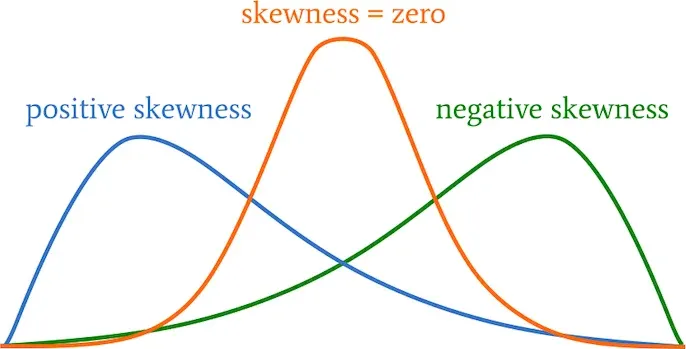

In [4]:
img_path = r'D:\Churn_Prediction\data\images\skewness.png'
from IPython.display import Image, display

display(Image(filename=img_path, width=400))

#### Outliers detection

In [29]:
# Statistical summary for numerical columns
print("NUMERICAL FEATURES SUMMARY")
print("="*26)
df.describe().T

NUMERICAL FEATURES SUMMARY


,count,mean,min,25%,50%,75%,max,std
age,4990.0,42.547635,-1.0,31.97804,42.140919,51.99275,999.0,19.911476
tenure_months,4990.0,24.107853,-12.0,6.836733,16.46817,33.814063,500.0,24.374937
monthly_charges,4988.0,70.065968,-50.0,47.6775,65.11,82.27,9999.0,212.236072
total_charges,4978.0,1645.915366,0.66,372.92,957.555,2125.1,218681.58,4201.398453
avg_monthly_gb_used,4985.0,15.181582,-86.55345,4.42,10.38,21.68,119.67,15.606634
num_support_tickets,5000.0,2.2708,-5.0,1.0,2.0,3.0,500.0,12.278698
avg_monthly_minutes,4920.0,299.331728,0.0,215.075,299.25,378.125,747.5,117.931522
satisfaction_score,4980.0,6.100161,-1.4,4.6,6.0,7.4,99.0,3.342552
num_additional_services,5000.0,2.4834,0.0,1.0,2.0,4.0,5.0,1.711464
last_interaction_date,5000,2024-06-01 13:04:48,2023-10-23 00:00:00,2024-05-21 00:00:00,2024-06-11 00:00:00,2024-06-22 00:00:00,2025-06-09 00:00:00,NaN


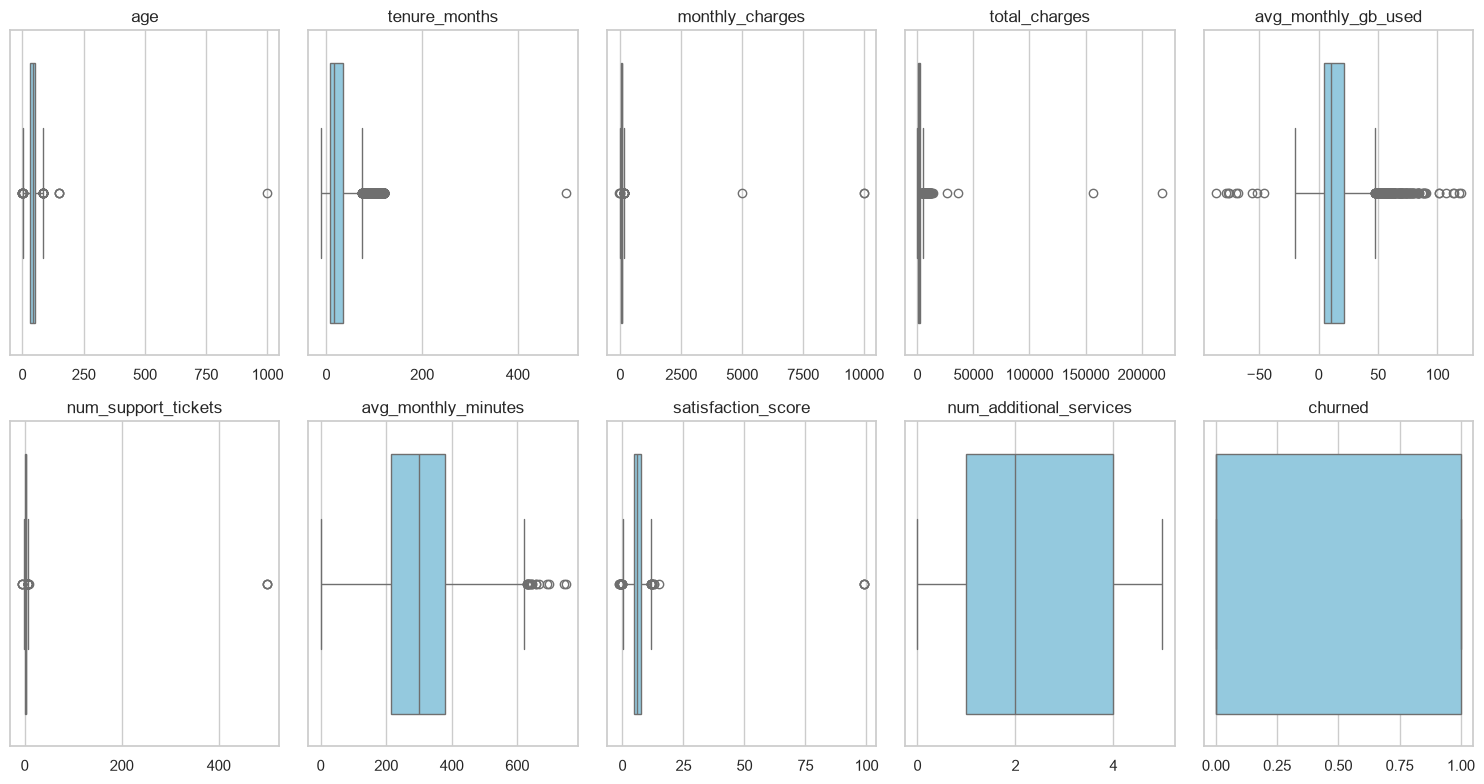

In [30]:
# Numeric columns
num_cols = df.select_dtypes(include='number').columns

# Number of plots
n = len(num_cols)

# Grid size
cols = 5  # Number of columns in the subplot grid
rows = math.ceil(n / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

# Draw boxplots
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
    ax.set_xlabel("")

# Remove unused subplots
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

#### Age

Average customer age: `42.5` years

~ Observed range: `-1 to 999` years (identified age values outside the acceptable business range of `18 to 100` years)

~ The presence of unrealistic values indicates data quality issues.

Negative ages and extremely high ages require validation and correction.

Action Required:
Replace invalid age values using appropriate imputation techniques.

In [31]:
df['age'].describe().T

count    4990.000000
mean       42.547635
std        19.911476
min        -1.000000
25%        31.978040
50%        42.140919
75%        51.992750
max       999.000000
Name: age, dtype: float64

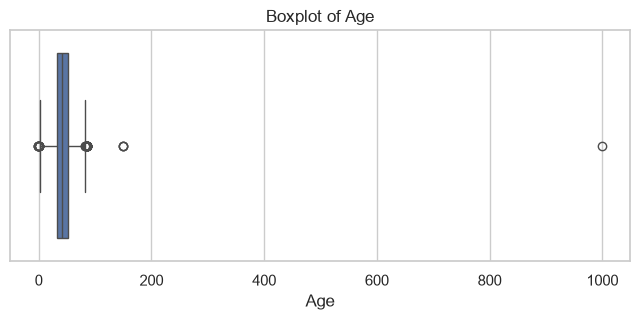

In [32]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['age'])

plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

In [33]:
df[df['age'] < 0]

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
1644,TC-000499,-1.0,Female,95.975494,One year,27.92,2727.22,DSL,Yes,8.85,2.0,209.0,3.4,Bank transfer,1,2024-06-29,1
4238,TC-001315,-1.0,Male,28.212851,Month-to-month,69.43,1985.71,No,No,1.66,1.0,450.2,6.5,Bank transfer,3,2024-06-27,1
644,TC-002352,-1.0,Male,21.514102,One year,29.19,640.81,Fiber,No,60.94,2.0,291.8,7.3,Bank transfer,4,2024-06-29,0
1466,TC-003785,-1.0,Male,9.179467,Month-to-month,105.37,931.41,No,No,6.78,3.0,348.3,6.1,Mailed check,3,2024-06-17,1


In [34]:
df[df['age'] > 100]

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
2533,TC-002231,150.0,Female,10.897770,One year,63.74,797.04,DSL,Yes,64.95,4.0,202.1,5.5,Bank transfer,5,2024-05-09,0
2838,TC-003464,150.0,Male,29.945151,Month-to-month,-10.00,288.20,Fiber optic,Yes,2.04,1.0,381.0,6.1,Bank transfer,5,2024-05-08,1
1107,TC-003905,150.0,Male,120.000000,Month-to-month,76.99,9270.88,DSL,Yes,11.05,5.0,190.4,5.0,Bank transfer,4,2024-05-23,1
805,TC-004250,999.0,Female,94.471391,Month-to-month,62.84,6126.25,NaN,Yes,15.42,2.0,382.0,3.6,Credit card,0,2024-05-18,0


In [35]:
df.loc[(df['age'] < 18) | (df['age'] > 100), 'age'] = np.nan

In [36]:
df[df["age"].isna()].shape[0]

30

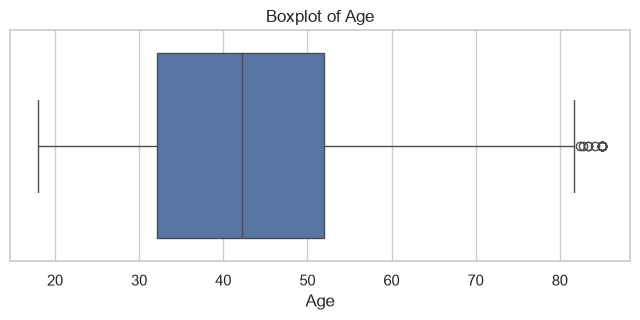

In [37]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['age'])

plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

#### Tenure Months

Average customer tenure: `24.1` months

Observed range: `-12 to 500` months

Negative tenure values and extremely high tenure values are not logically valid.

In [38]:
df['tenure_months'].describe().T

count    4990.000000
mean       24.107853
std        24.374937
min       -12.000000
25%         6.836733
50%        16.468170
75%        33.814063
max       500.000000
Name: tenure_months, dtype: float64

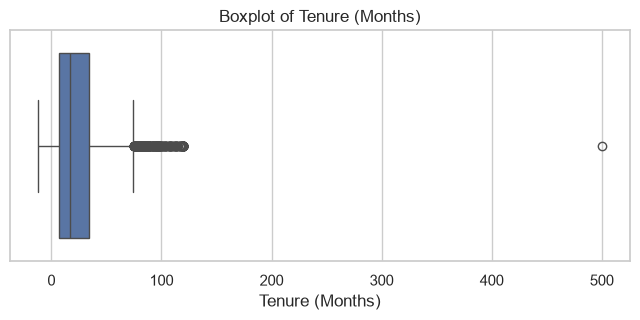

In [39]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['tenure_months'])
    
plt.title("Boxplot of Tenure (Months)")
plt.xlabel("Tenure (Months)")
plt.show()

In [40]:
print("tenure months less than 0 customers:", df[df['tenure_months'] < 0].shape[0])
print("tenure months greater than 120 customers:", df[df['tenure_months'] > 120].shape[0])

tenure months less than 0 customers: 4
tenure months greater than 120 customers: 1


In [41]:
df.loc[df['tenure_months'] < 0, 'tenure_months'] = np.nan

df.loc[df['tenure_months'] > 120, 'tenure_months'] = np.nan

In [42]:
df['tenure_months'].describe(include="all").T

count    4985.000000
mean       24.034742
std        23.423218
min         1.000000
25%         6.848197
50%        16.510977
75%        33.820759
max       120.000000
Name: tenure_months, dtype: float64

In [43]:
df['tenure_months'].fillna(
    df['tenure_months'].median(),
    inplace=True
)

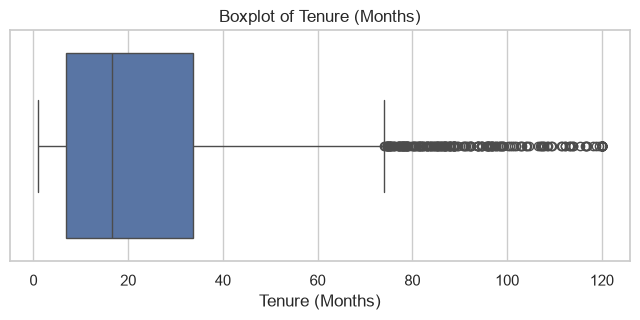

In [44]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['tenure_months'])
    
plt.title("Boxplot of Tenure (Months)")
plt.xlabel("Tenure (Months)")
plt.show()

#### Monthly Charges

`Average monthly charges`: 70.06

`Observed range`: -50 to 9,999

`Negative` charges and unusually high charges indicate possible data entry errors.

In [45]:
df['monthly_charges'].describe(include="all").T

count    4988.000000
mean       70.065968
std       212.236072
min       -50.000000
25%        47.677500
50%        65.110000
75%        82.270000
max      9999.000000
Name: monthly_charges, dtype: float64

In [46]:
print("monthly charges less than 0 customers:", df[df['monthly_charges'] < 0].shape[0])
print("monthly charges greater than 500 customers:", df[df['monthly_charges'] > 500].shape[0])

monthly charges less than 0 customers: 3
monthly charges greater than 500 customers: 3


In [47]:
df['monthly_charges'].describe(include="all").T

count    4988.000000
mean       70.065968
std       212.236072
min       -50.000000
25%        47.677500
50%        65.110000
75%        82.270000
max      9999.000000
Name: monthly_charges, dtype: float64

In [48]:
df.loc[df['monthly_charges'] < 0, 'monthly_charges'] = np.nan
df.loc[df['monthly_charges'] > 500, 'monthly_charges'] = np.nan

In [49]:
df['monthly_charges'].describe(include="all").T

count    4982.000000
mean       65.146738
std        24.605585
min         0.000000
25%        47.717500
50%        65.110000
75%        82.260000
max       150.000000
Name: monthly_charges, dtype: float64

In [50]:
df['monthly_charges'].fillna(
    df['monthly_charges'].median(),
    inplace=True
)

df['monthly_charges'].isna().sum()

np.int64(0)

#### Support Tickets

In [51]:
df['num_support_tickets'].describe(include="all").T

count    5000.000000
mean        2.270800
std        12.278698
min        -5.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       500.000000
Name: num_support_tickets, dtype: float64

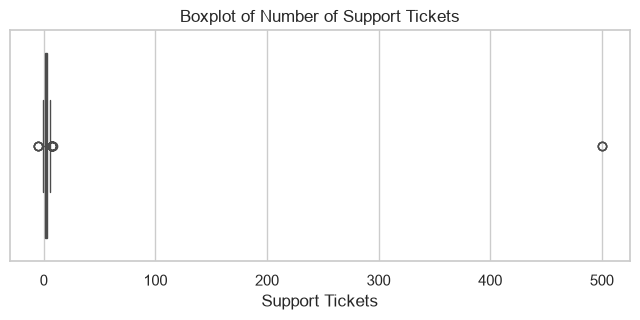

In [52]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['num_support_tickets'])

plt.title("Boxplot of Number of Support Tickets")
plt.xlabel("Support Tickets")
plt.show()

In [53]:
df['num_support_tickets'].describe(include="all").T

count    5000.000000
mean        2.270800
std        12.278698
min        -5.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       500.000000
Name: num_support_tickets, dtype: float64

In [54]:
print("num support tickets less than 0 customers:", df[df['num_support_tickets'] < 0].shape[0])
# print("num support tickets greater than 10 customers:", df[df['num_support_tickets'] > 10].shape[0])
# print("num support tickets greater than 20 customers:", df[df['num_support_tickets'] > 20].shape[0])
print("num support tickets greater than 50 customers:", df[df['num_support_tickets'] > 50].shape[0])

num support tickets less than 0 customers: 7
num support tickets greater than 50 customers: 3


In [55]:
df.loc[df['num_support_tickets'] < 0, 'num_support_tickets'] = np.nan

df.loc[df['num_support_tickets'] > 50, 'num_support_tickets'] = np.nan

In [56]:
df['num_support_tickets'].describe(include="all").T

count    4990.000000
mean        1.979359
std         1.402320
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: num_support_tickets, dtype: float64

In [57]:
df['num_support_tickets'].isna().sum()

np.int64(10)

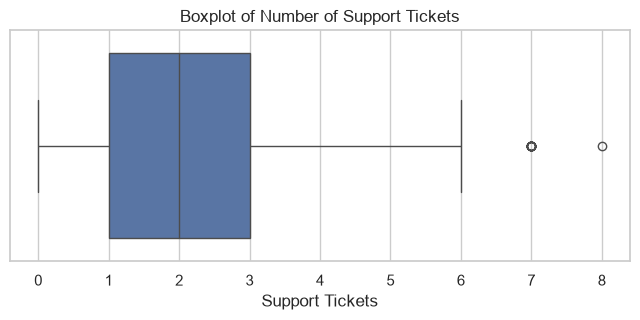

In [58]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['num_support_tickets'])

plt.title("Boxplot of Number of Support Tickets")
plt.xlabel("Support Tickets")
plt.show()

#### Internet Service

In [59]:
# Missing internet_service with usage
with_use = (
    df["internet_service"].isna() &
    (df["avg_monthly_gb_used"] > 0)
).sum()

# Missing internet_service without usage
without_use = (
    df["internet_service"].isna() &
    ((df["avg_monthly_gb_used"].isna()) | (df["avg_monthly_gb_used"] == 0))
).sum()

print("Missing internet_service with usage:", with_use)
print("Missing internet_service without usage:", without_use)

Missing internet_service with usage: 493
Missing internet_service without usage: 2


In [60]:
missing_internet = df[df["internet_service"].isna()]
print(len(missing_internet))

print("Positive usage:",
      (missing_internet["avg_monthly_gb_used"] > 0).sum())

print("Zero usage:",
      (missing_internet["avg_monthly_gb_used"] == 0).sum())

print("Missing usage:",
      missing_internet["avg_monthly_gb_used"].isna().sum())

print("Negative usage:",
      (missing_internet["avg_monthly_gb_used"] < 0).sum())

497
Positive usage: 493
Zero usage: 0
Missing usage: 2
Negative usage: 2


In [61]:
df["avg_monthly_gb_used"] = df["avg_monthly_gb_used"].abs()

# # Fix negative usage first
# df.loc[
#     df["avg_monthly_gb_used"] < 0,
#     "avg_monthly_gb_used"
# ] = np.nan

In [62]:
df[df["internet_service"].isna()]["churned"].value_counts(normalize=True)

# df[df["internet_service"].isna()]["churned"].value_counts()

churned
0    0.617706
1    0.382294
Name: proportion, dtype: float64

In [63]:
missing_churn = df[df["internet_service"].isna()]["churned"].mean()
overall_churn = df["churned"].mean()

print("Missing internet_service churn rate:", missing_churn)
print("Overall churn rate:", overall_churn)

Missing internet_service churn rate: 0.3822937625754527
Overall churn rate: 0.3646


In [64]:
# Assign unknown category for missing internet service
df["internet_service"] = df["internet_service"].fillna("Unknown")

#### Data Usage (Average Monthly GB Used)

`Average monthly usage`: 15.18 GB

`Range`: -86.55 to 119.67 GB

Negative usage values are invalid.

In [65]:
df['avg_monthly_gb_used'].describe(include="all").T

count    4985.000000
mean       15.433347
std        15.357659
min         0.000000
25%         4.470000
50%        10.450000
75%        21.780000
max       119.670000
Name: avg_monthly_gb_used, dtype: float64

In [66]:
print("num customers with avg_monthly_gb_used < 0:", df[df['avg_monthly_gb_used'] < 0].shape[0])
print("num customers with avg_monthly_gb_used > 100:", df[df['avg_monthly_gb_used'] > 100].shape[0])

num customers with avg_monthly_gb_used < 0: 0
num customers with avg_monthly_gb_used > 100: 7


In [67]:
df['avg_monthly_gb_used'] = df['avg_monthly_gb_used'].fillna(
    df['avg_monthly_gb_used'].median()
)

#### Monthly Minutes Usage

`Average usage`: 299.33 minutes

`Range`: 0 to 747.5 minutes

Values appear within a reasonable range.

In [68]:
df['avg_monthly_minutes'].describe(include="all").T

count    4920.000000
mean      299.331728
std       117.931522
min         0.000000
25%       215.075000
50%       299.250000
75%       378.125000
max       747.500000
Name: avg_monthly_minutes, dtype: float64

In [69]:
skew_value = df['avg_monthly_minutes'].skew()

print("Skewness:", skew_value)

Skewness: 0.08520504024601108


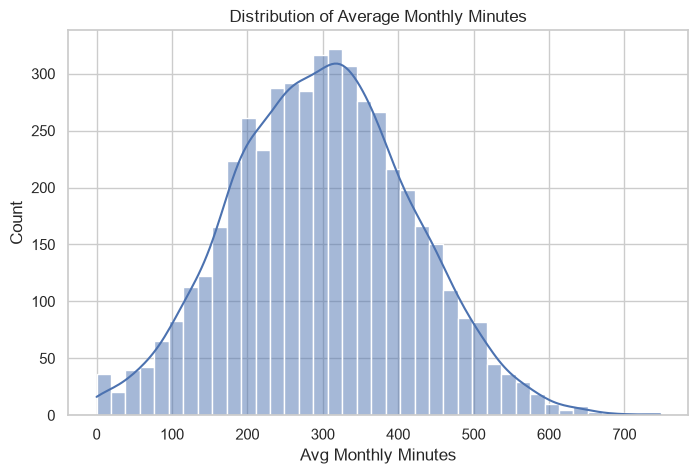

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['avg_monthly_minutes'], kde=True)
plt.title("Distribution of Average Monthly Minutes")
plt.xlabel("Avg Monthly Minutes")
plt.show()

In [71]:
df.groupby('phone_service')['avg_monthly_minutes'].describe()

,count,mean,std,min,25%,50%,75%,max
phone_service,,,,,,,,
No,1792.0,304.243025,117.574233,0.0,218.7,305.05,383.75,691.4
Yes,3128.0,296.518095,118.062453,0.0,213.6,296.05,375.30,747.5


In [72]:
# Customers without phone service
df.loc[df['phone_service'] == 'No', 'avg_monthly_minutes'] = (
    df.loc[df['phone_service'] == 'No', 'avg_monthly_minutes'].fillna(0)
)

# Customers with phone service
median_minutes = df.loc[df['phone_service'] == 'Yes', 'avg_monthly_minutes'].median()

df.loc[df['phone_service'] == 'Yes', 'avg_monthly_minutes'] = (
    df.loc[df['phone_service'] == 'Yes', 'avg_monthly_minutes'].fillna(median_minutes)
)


df[df['phone_service']=='No'][['customer_id','phone_service','avg_monthly_minutes']].sort_values(
    'avg_monthly_minutes', ascending=False
).head(10)

,customer_id,phone_service,avg_monthly_minutes
4830,TC-002057,No,691.4
2748,TC-001812,No,666.2
4581,TC-001366,No,656.4
579,TC-001262,No,645.6
2260,TC-004140,No,642.9
2385,TC-003227,No,635.9
3156,TC-000270,No,633.7
1146,TC-001972,No,630.6
4852,TC-003220,No,629.9
3134,TC-002353,No,611.2


In [73]:
df['avg_monthly_minutes'] = df.groupby('phone_service')['avg_monthly_minutes'].transform(
    lambda x: x.fillna(x.median())
)

#### Satisfaction Score
Average satisfaction score: 6.1
Range: -1.4 to 99
Values outside the expected rating scale indicate invalid records.

In [74]:
df['satisfaction_score'].describe(include="all").T

count    4980.000000
mean        6.100161
std         3.342552
min        -1.400000
25%         4.600000
50%         6.000000
75%         7.400000
max        99.000000
Name: satisfaction_score, dtype: float64

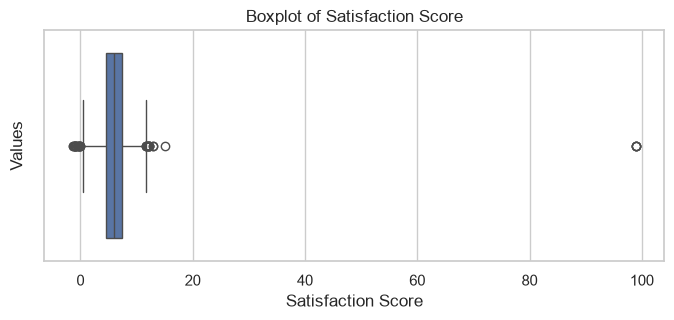

In [75]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['satisfaction_score'])

plt.title("Boxplot of Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Values")
plt.show()

In [76]:
print("num customers with satisfaction score < 0:", df[df['satisfaction_score'] < 0].shape[0])
print("num customers with satisfaction score > 10:", df[df['satisfaction_score'] > 10].shape[0])

num customers with satisfaction score < 0: 14
num customers with satisfaction score > 10: 126


In [77]:
df.loc[
    (df['satisfaction_score'] < 0) |
    (df['satisfaction_score'] > 10),
    'satisfaction_score'
] = np.nan

In [78]:
df['satisfaction_score'].fillna(
    df['satisfaction_score'].median(),
    inplace=True
)

In [79]:
# df['satisfaction_score'].describe(include="all").T

# plt.figure(figsize=(8,3))
# sns.boxplot(x=df['satisfaction_score'])

# plt.title("Boxplot of Satisfaction Score")
# plt.xlabel("Satisfaction Score")
# plt.ylabel("Values")
# plt.show()

## Part 4: Save Data Set

In [ ]:
import os
import re
from datetime import datetime

output_folder = "D:/Churn_Prediction/data/Pre_processed_data"


os.makedirs(output_folder, exist_ok=True)


files = os.listdir(output_folder)

# Find existing versions
versions = []

for file in files:
    match = re.search(r"churn_data_v(\d+)", file)
    if match:
        versions.append(int(match.group(1)))

# Increment version
if versions:
    next_version = max(versions) + 1
else:
    next_version = 1

# Create filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"churn_data_v{next_version}_{timestamp}.csv"

filepath = os.path.join(output_folder, filename)

# Save dataset
df.to_csv(filepath, index=False)

print(f"Saved file: {filepath}")

Saved file: D:/AI_ML_Assessment/data/pre_processed_data\char_data_v1_20260721_161051.csv
